# SkinSense — Klasifikasi Tipe Kulit Wajah
## Perbandingan 3 Arsitektur CNN × 3 Class Weight (9 Skenario)

**Urutan sel:**
1. Pengaturan & Konfigurasi
2. Import & Persiapan
3. Dataset & DataLoader
4. Fungsi Bangun Model
5. Fungsi Latih & Evaluasi (menghasilkan grafik per skenario)
6. Jalankan 9 Skenario
7. Tabel Perbandingan
8. Grafik Perbandingan (Recall Normal & F1 Macro)
9. Penentuan Model Terbaik
10. Grafik Perbandingan 3 Arsitektur pada Class Weight Terbaik

In [1]:
# ================================================================
# SEL 1: PENGATURAN & KONFIGURASI
# ================================================================

import os

# --- Path Dataset ---
DATA_DIR = "/kaggle/input/datasets/dilaaurafutri/skin-type-classification-4-types/dataset_skintype_vit_final_crop"

# --- Arsitektur & Class Weight ---
DAFTAR_ARSITEKTUR = ["efficientnet_b0", "mobilenet_v2", "densenet121"]
DAFTAR_BOBOT      = [1.0, 1.5, 2.0]
NAMA_KELAS        = ["combination", "dry", "normal", "oily"]
LABEL_INDO        = ["Kombinasi", "Kering", "Normal", "Berminyak"]

# --- Hyperparameter ---
UKURAN_RESIZE = 256
UKURAN_CROP   = 224
BATCH_SIZE    = 32
DROPOUT       = 0.4
WEIGHT_DECAY  = 0.0005
LEARNING_RATE = 0.00005  # 5e-5, lebih kecil & stabil
MAX_EPOCH     = 30
PATIENCE      = 5
SEED          = 42

# --- Folder Output ---
FIG_DIR = "/kaggle/working/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Konfigurasi selesai.")
print("Dataset :", DATA_DIR)
print("Output  :", FIG_DIR)

Konfigurasi selesai.
Dataset : /kaggle/input/datasets/dilaaurafutri/skin-type-classification-4-types/dataset_skintype_vit_final_crop
Output  : /kaggle/working/figures


In [2]:
# ================================================================
# SEL 2: IMPORT & PERSIAPAN
# ================================================================

import random
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Fungsi Seed ---
def kunci_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

kunci_seed(SEED)
print("Seed dikunci:", SEED)

Device: cuda
Seed dikunci: 42


In [3]:
# ================================================================
# SEL 3: DATASET & DATALOADER
# ================================================================

# ImageNet mean & std untuk normalisasi
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Transformasi data latih (dengan augmentasi)
transform_latih = transforms.Compose([
    transforms.Resize(UKURAN_RESIZE),
    transforms.RandomResizedCrop(UKURAN_CROP, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Transformasi data validasi & uji (tanpa augmentasi)
transform_eval = transforms.Compose([
    transforms.Resize(UKURAN_RESIZE),
    transforms.CenterCrop(UKURAN_CROP),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Muat dataset
data_latih    = datasets.ImageFolder(DATA_DIR + "/train", transform=transform_latih)
data_validasi = datasets.ImageFolder(DATA_DIR + "/valid", transform=transform_eval)
data_uji      = datasets.ImageFolder(DATA_DIR + "/test",  transform=transform_eval)

# DataLoader
loader_latih    = DataLoader(data_latih,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
loader_validasi = DataLoader(data_validasi, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
loader_uji      = DataLoader(data_uji,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Data latih    : {len(data_latih):>5} citra")
print(f"Data validasi : {len(data_validasi):>5} citra")
print(f"Data uji      : {len(data_uji):>5} citra")
print(f"Kelas         : {data_latih.classes}")

Data latih    :  1599 citra
Data validasi :   200 citra
Data uji      :   200 citra
Kelas         : ['combination', 'dry', 'normal', 'oily']


In [4]:
# ================================================================
# SEL 4: FUNGSI BANGUN MODEL
# ================================================================

def bangun_model(arch):
    """Memuat arsitektur dengan pre-trained ImageNet,
    mengganti lapisan klasifikasi dengan 4 kelas + dropout."""
    if arch == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        jf = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(jf, 4))

    elif arch == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        jf = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(jf, 4))

    elif arch == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        jf = model.classifier.in_features
        model.classifier = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(jf, 4))

    else:
        raise ValueError("Arsitektur tidak dikenal: " + arch)

    return model.to(device)

print("Fungsi bangun_model siap.")

Fungsi bangun_model siap.


In [5]:
# ================================================================
# SEL 5: FUNGSI LATIH & EVALUASI
# ================================================================
# Menghasilkan per skenario:
#   Grafik 1 — Kurva Akurasi & Loss (train vs validasi)
#   Grafik 2 — Confusion Matrix (data uji)
#   Grafik 3 — Metrik per Kelas (data uji)
# Mengembalikan dict metrik untuk tabel perbandingan.
# ================================================================

def latih_dan_evaluasi(arch, bobot):
    tag = f"{arch}_w{bobot}"
    label_judul = f"{arch.replace('_', ' ').title()} — Class Weight {bobot}"

    print()
    print("=" * 60)
    print(f"TRAINING: {arch}  |  NORMAL_WEIGHT = {bobot}")
    print("=" * 60)

    kunci_seed(SEED)
    model     = bangun_model(arch)
    bobot_kelas = torch.tensor([1.0, 1.0, bobot, 1.0]).to(device)
    # Label smoothing 0.1 untuk mencegah model terlalu percaya diri (anti-overfitting)
    criterion = nn.CrossEntropyLoss(weight=bobot_kelas, label_smoothing=0.1)

    # Learning rate seragam 5e-5 untuk seluruh arsitektur
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # ReduceLROnPlateau: turunkan LR otomatis kalau F1 validasi stagnan
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    # Riwayat untuk kurva
    r_epoch, r_loss_latih, r_acc_latih = [], [], []
    r_loss_val,  r_acc_val             = [], []

    f1_terbaik          = 0.0
    hitung_tidak_membaik = 0
    path_checkpoint     = f"/kaggle/working/best_{tag}.pth"

    # ---- Loop epoch ----
    for epoch in range(1, MAX_EPOCH + 1):

        # Fase latih
        model.train()
        total_loss_latih = 0.0
        benar_latih      = 0
        for gambar, label in loader_latih:
            gambar, label = gambar.to(device), label.to(device)
            keluaran = model(gambar)
            loss     = criterion(keluaran, label)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss_latih += loss.item() * gambar.size(0)
            benar_latih      += (keluaran.argmax(1) == label).sum().item()

        loss_latih = total_loss_latih / len(data_latih)
        acc_latih  = benar_latih      / len(data_latih)

        # Fase validasi
        model.eval()
        total_loss_val      = 0.0
        prediksi_val, label_val = [], []
        with torch.no_grad():
            for gambar, label in loader_validasi:
                gambar, label = gambar.to(device), label.to(device)
                keluaran      = model(gambar)
                loss          = criterion(keluaran, label)
                total_loss_val += loss.item() * gambar.size(0)
                prediksi_val.extend(keluaran.argmax(1).cpu().numpy())
                label_val.extend(label.cpu().numpy())

        loss_val  = total_loss_val / len(data_validasi)
        acc_val   = accuracy_score(label_val, prediksi_val)
        f1_val    = f1_score(label_val, prediksi_val, average="macro")
        gap       = (acc_latih - acc_val) * 100

        r_epoch.append(epoch)
        r_loss_latih.append(loss_latih);  r_acc_latih.append(acc_latih)
        r_loss_val.append(loss_val);      r_acc_val.append(acc_val)

        print(f"Epoch {epoch:>2} | Acc latih {acc_latih*100:.2f}% "
              f"| Acc val {acc_val*100:.2f}% "
              f"| F1 val {f1_val*100:.2f}% "
              f"| Gap {gap:+.1f}%")

        scheduler.step(f1_val)

        if f1_val > f1_terbaik:
            f1_terbaik           = f1_val
            hitung_tidak_membaik = 0
            torch.save(model.state_dict(), path_checkpoint)
        else:
            hitung_tidak_membaik += 1
            if hitung_tidak_membaik >= PATIENCE:
                print(f"   >> Early stopping di epoch {epoch}")
                break

    # ---- GRAFIK 1: Kurva Akurasi & Loss ----
    acc_latih_pct = [a * 100 for a in r_acc_latih]
    acc_val_pct   = [a * 100 for a in r_acc_val]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f"Kurva Akurasi & Loss — {label_judul}", fontsize=12, fontweight="bold")

    axes[0].plot(r_epoch, acc_latih_pct, "o-", label="Train", color="steelblue")
    axes[0].plot(r_epoch, acc_val_pct,   "s-", label="Validation", color="darkorange")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Akurasi (%)")
    axes[0].set_title("Kurva Akurasi"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(r_epoch, r_loss_latih, "o-", label="Train", color="steelblue")
    axes[1].plot(r_epoch, r_loss_val,   "s-", label="Validation", color="darkorange")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title("Kurva Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/1_kurva_{tag}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- Evaluasi pada data uji (checkpoint terbaik) ----
    model.load_state_dict(torch.load(path_checkpoint))
    model.eval()
    prediksi_uji, label_uji = [], []
    with torch.no_grad():
        for gambar, label in loader_uji:
            gambar = gambar.to(device)
            keluaran = model(gambar)
            prediksi_uji.extend(keluaran.argmax(1).cpu().numpy())
            label_uji.extend(label.numpy())

    akurasi  = accuracy_score(label_uji,  prediksi_uji)
    presisi  = precision_score(label_uji, prediksi_uji, average="macro")
    recall   = recall_score(label_uji,    prediksi_uji, average="macro")
    f1       = f1_score(label_uji,        prediksi_uji, average="macro")
    recall_per_kelas = recall_score(label_uji, prediksi_uji, average=None)
    recall_normal    = recall_per_kelas[2]  # indeks 2 = normal

    print(f"\nHASIL TEST {tag}:")
    print(f"  Accuracy  : {akurasi*100:.2f}%")
    print(f"  Precision : {presisi*100:.2f}%")
    print(f"  Recall    : {recall*100:.2f}%")
    print(f"  F1 Macro  : {f1*100:.2f}%")
    print(f"  Recall Normal: {recall_normal*100:.2f}%")
    print()
    print(classification_report(label_uji, prediksi_uji,
                                target_names=NAMA_KELAS, digits=4))

    # ---- GRAFIK 2: Confusion Matrix ----
    cm = confusion_matrix(label_uji, prediksi_uji)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABEL_INDO, yticklabels=LABEL_INDO,
                cbar=False, linewidths=0.5)
    ax.set_xlabel("Prediksi", fontsize=11)
    ax.set_ylabel("Aktual",   fontsize=11)
    ax.set_title(f"Confusion Matrix — {label_judul}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/2_confusion_{tag}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- GRAFIK 3: Metrik per Kelas ----
    prec_k = precision_score(label_uji, prediksi_uji, average=None)
    rec_k  = recall_score(label_uji,    prediksi_uji, average=None)
    f1_k   = f1_score(label_uji,        prediksi_uji, average=None)

    posisi = np.arange(4)
    lebar  = 0.25
    warna  = ["steelblue", "darkorange", "seagreen"]

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(posisi - lebar, prec_k * 100, lebar, label="Precision", color=warna[0])
    b2 = ax.bar(posisi,          rec_k  * 100, lebar, label="Recall",    color=warna[1])
    b3 = ax.bar(posisi + lebar,  f1_k   * 100, lebar, label="F1-score",  color=warna[2])

    for bar in [b1, b2, b3]:
        ax.bar_label(bar, fmt="%.1f", fontsize=8, padding=2)

    ax.set_xticks(posisi)
    ax.set_xticklabels(LABEL_INDO, fontsize=10)
    ax.set_ylabel("Skor (%)"); ax.set_ylim(0, 110)
    ax.set_title(f"Metrik per Kelas — {label_judul}", fontsize=11, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/3_per_kelas_{tag}.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "akurasi": akurasi, "presisi": presisi,
        "recall": recall,   "f1": f1,
        "recall_normal": recall_normal,
        "r_epoch": r_epoch,
        "r_acc_latih": r_acc_latih, "r_acc_val": r_acc_val,
        "r_loss_latih": r_loss_latih, "r_loss_val": r_loss_val,
    }

print("Fungsi latih_dan_evaluasi siap.")

Fungsi latih_dan_evaluasi siap.



TRAINING: efficientnet_b0  |  NORMAL_WEIGHT = 1.0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 96.7MB/s]


Epoch  1 | Acc latih 37.21% | Acc val 50.50% | F1 val 48.75% | Gap -13.3%
Epoch  2 | Acc latih 54.66% | Acc val 61.00% | F1 val 60.16% | Gap -6.3%
Epoch  3 | Acc latih 60.98% | Acc val 62.00% | F1 val 61.42% | Gap -1.0%
Epoch  4 | Acc latih 64.98% | Acc val 64.50% | F1 val 63.98% | Gap +0.5%
Epoch  5 | Acc latih 68.04% | Acc val 65.50% | F1 val 64.80% | Gap +2.5%
Epoch  6 | Acc latih 71.98% | Acc val 68.00% | F1 val 67.10% | Gap +4.0%
Epoch  7 | Acc latih 73.73% | Acc val 70.00% | F1 val 69.70% | Gap +3.7%
Epoch  8 | Acc latih 75.11% | Acc val 72.50% | F1 val 72.14% | Gap +2.6%
Epoch  9 | Acc latih 76.61% | Acc val 72.00% | F1 val 71.46% | Gap +4.6%
Epoch 10 | Acc latih 77.30% | Acc val 71.50% | F1 val 70.96% | Gap +5.8%
Epoch 11 | Acc latih 80.05% | Acc val 72.00% | F1 val 71.47% | Gap +8.1%
Epoch 12 | Acc latih 80.93% | Acc val 70.50% | F1 val 69.92% | Gap +10.4%
Epoch 13 | Acc latih 82.18% | Acc val 71.00% | F1 val 70.41% | Gap +11.2%
   >> Early stopping di epoch 13


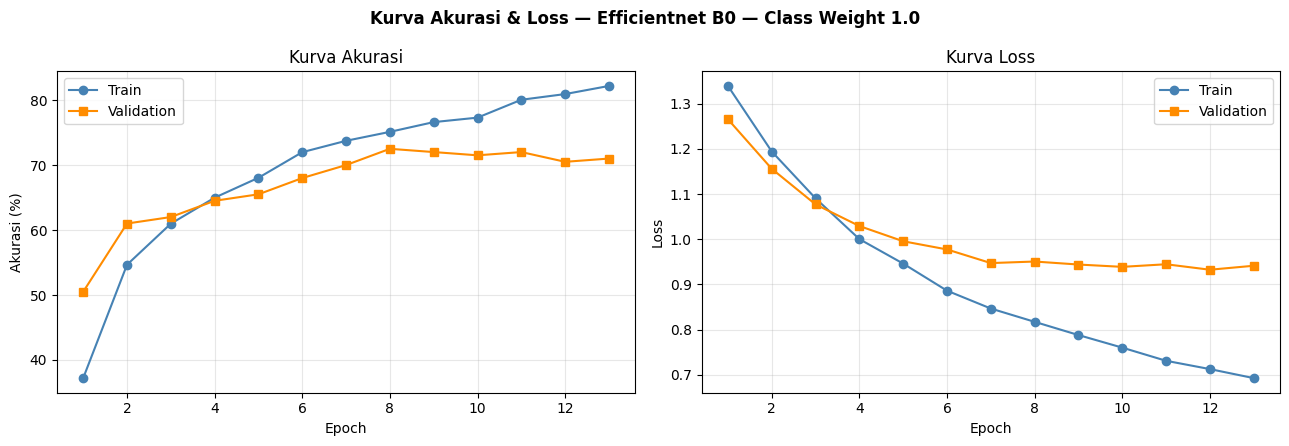


HASIL TEST efficientnet_b0_w1.0:
  Accuracy  : 76.00%
  Precision : 80.31%
  Recall    : 76.00%
  F1 Macro  : 75.56%
  Recall Normal: 50.00%

              precision    recall  f1-score   support

 combination     0.7600    0.7600    0.7600        50
         dry     0.8776    0.8600    0.8687        50
      normal     0.9615    0.5000    0.6579        50
        oily     0.6133    0.9200    0.7360        50

    accuracy                         0.7600       200
   macro avg     0.8031    0.7600    0.7556       200
weighted avg     0.8031    0.7600    0.7556       200



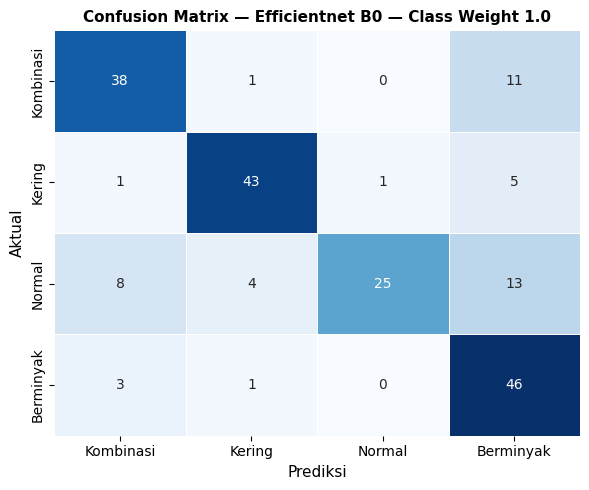

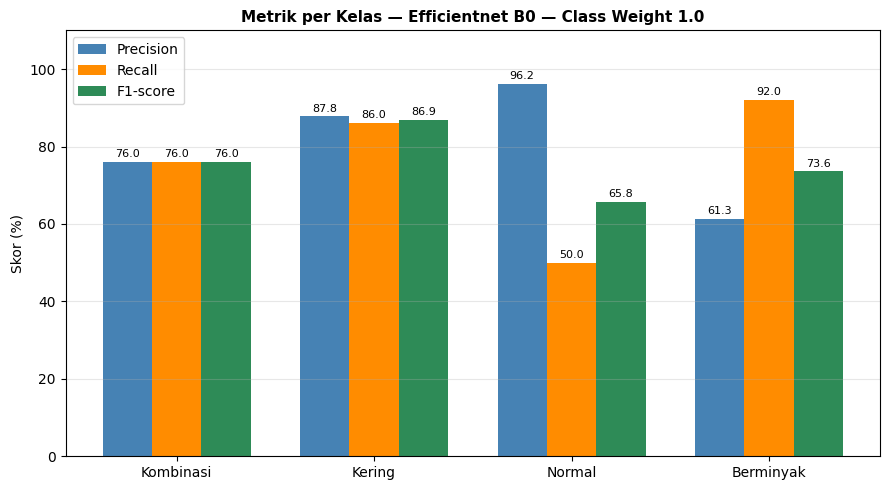


TRAINING: efficientnet_b0  |  NORMAL_WEIGHT = 1.5
Epoch  1 | Acc latih 37.09% | Acc val 51.00% | F1 val 49.67% | Gap -13.9%
Epoch  2 | Acc latih 52.16% | Acc val 58.50% | F1 val 58.01% | Gap -6.3%
Epoch  3 | Acc latih 59.04% | Acc val 61.00% | F1 val 60.60% | Gap -2.0%
Epoch  4 | Acc latih 65.17% | Acc val 64.00% | F1 val 63.51% | Gap +1.2%
Epoch  5 | Acc latih 66.98% | Acc val 65.50% | F1 val 65.18% | Gap +1.5%
Epoch  6 | Acc latih 71.17% | Acc val 66.00% | F1 val 65.62% | Gap +5.2%
Epoch  7 | Acc latih 72.92% | Acc val 68.00% | F1 val 67.67% | Gap +4.9%
Epoch  8 | Acc latih 74.86% | Acc val 70.00% | F1 val 69.68% | Gap +4.9%
Epoch  9 | Acc latih 76.05% | Acc val 70.50% | F1 val 69.95% | Gap +5.5%
Epoch 10 | Acc latih 77.61% | Acc val 69.50% | F1 val 68.93% | Gap +8.1%
Epoch 11 | Acc latih 80.55% | Acc val 70.50% | F1 val 69.94% | Gap +10.1%
Epoch 12 | Acc latih 80.68% | Acc val 70.00% | F1 val 69.53% | Gap +10.7%
Epoch 13 | Acc latih 81.99% | Acc val 71.00% | F1 val 70.52% | Gap +11

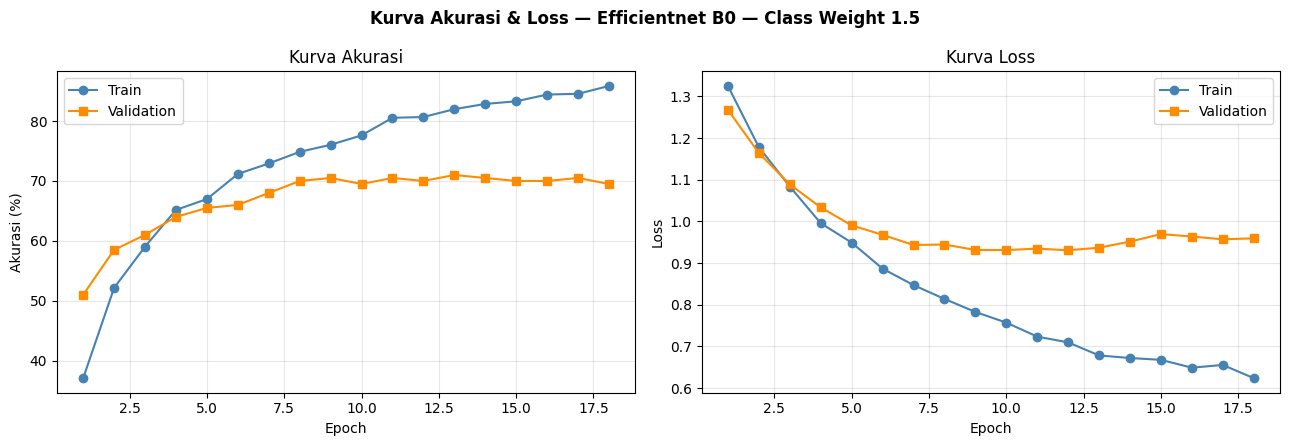


HASIL TEST efficientnet_b0_w1.5:
  Accuracy  : 74.50%
  Precision : 77.72%
  Recall    : 74.50%
  F1 Macro  : 74.20%
  Recall Normal: 52.00%

              precision    recall  f1-score   support

 combination     0.7400    0.7400    0.7400        50
         dry     0.8889    0.8000    0.8421        50
      normal     0.8667    0.5200    0.6500        50
        oily     0.6133    0.9200    0.7360        50

    accuracy                         0.7450       200
   macro avg     0.7772    0.7450    0.7420       200
weighted avg     0.7772    0.7450    0.7420       200



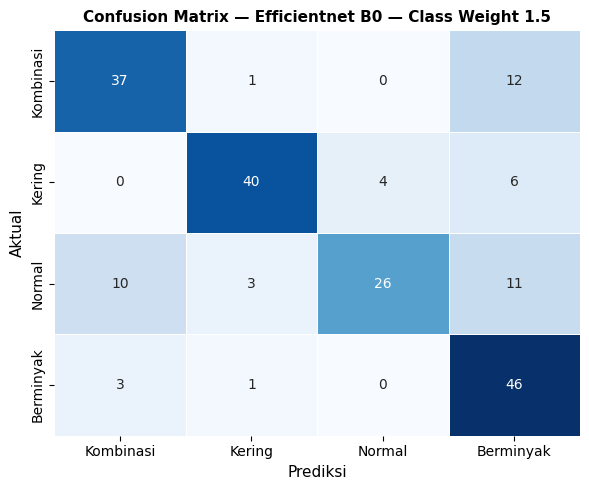

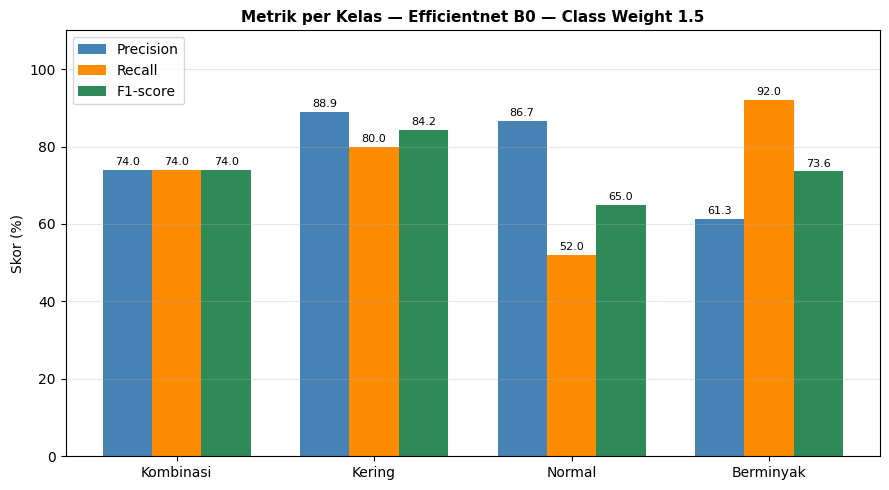


TRAINING: efficientnet_b0  |  NORMAL_WEIGHT = 2.0
Epoch  1 | Acc latih 35.52% | Acc val 47.50% | F1 val 44.70% | Gap -12.0%
Epoch  2 | Acc latih 49.66% | Acc val 56.50% | F1 val 55.86% | Gap -6.8%
Epoch  3 | Acc latih 56.22% | Acc val 60.50% | F1 val 60.05% | Gap -4.3%
Epoch  4 | Acc latih 62.10% | Acc val 63.00% | F1 val 62.62% | Gap -0.9%
Epoch  5 | Acc latih 64.85% | Acc val 64.50% | F1 val 64.25% | Gap +0.4%
Epoch  6 | Acc latih 68.61% | Acc val 65.00% | F1 val 64.79% | Gap +3.6%
Epoch  7 | Acc latih 71.42% | Acc val 65.50% | F1 val 65.21% | Gap +5.9%
Epoch  8 | Acc latih 73.92% | Acc val 68.50% | F1 val 68.22% | Gap +5.4%
Epoch  9 | Acc latih 74.98% | Acc val 70.50% | F1 val 70.04% | Gap +4.5%
Epoch 10 | Acc latih 76.42% | Acc val 70.00% | F1 val 69.59% | Gap +6.4%
Epoch 11 | Acc latih 78.67% | Acc val 70.00% | F1 val 69.55% | Gap +8.7%
Epoch 12 | Acc latih 79.80% | Acc val 69.00% | F1 val 68.62% | Gap +10.8%
Epoch 13 | Acc latih 80.36% | Acc val 70.00% | F1 val 69.56% | Gap +10.

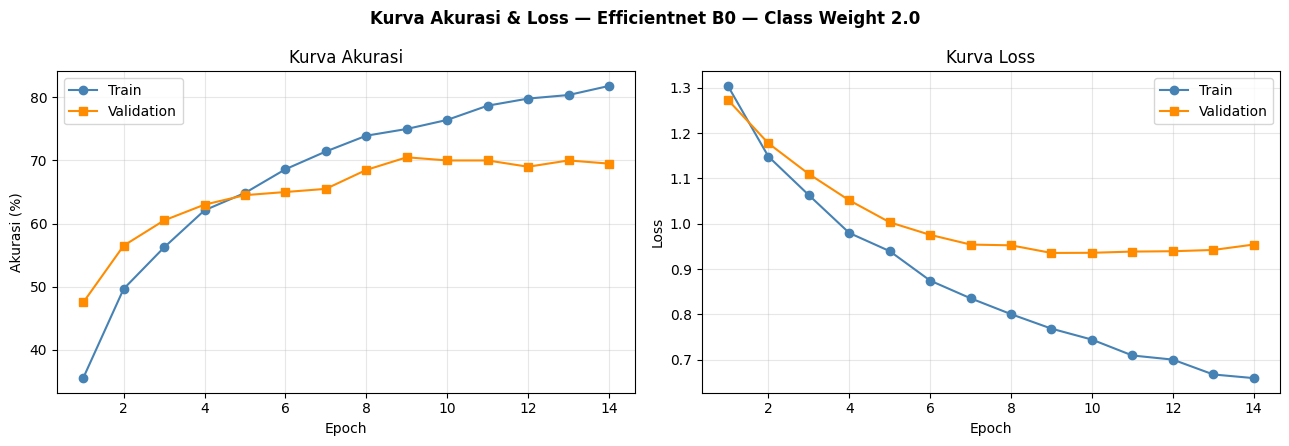


HASIL TEST efficientnet_b0_w2.0:
  Accuracy  : 75.00%
  Precision : 77.41%
  Recall    : 75.00%
  F1 Macro  : 75.02%
  Recall Normal: 68.00%

              precision    recall  f1-score   support

 combination     0.8205    0.6400    0.7191        50
         dry     0.8636    0.7600    0.8085        50
      normal     0.7907    0.6800    0.7312        50
        oily     0.6216    0.9200    0.7419        50

    accuracy                         0.7500       200
   macro avg     0.7741    0.7500    0.7502       200
weighted avg     0.7741    0.7500    0.7502       200



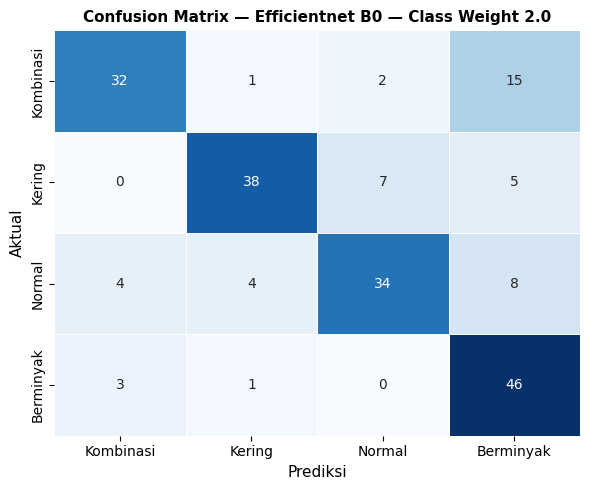

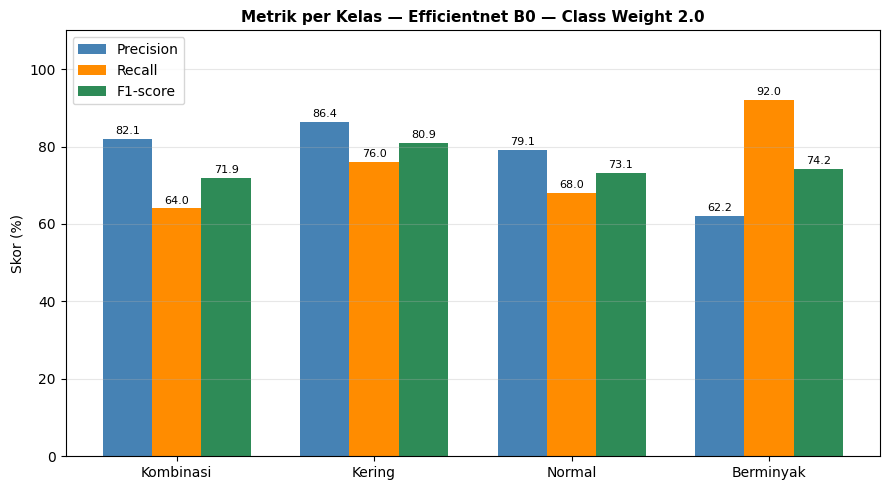


TRAINING: mobilenet_v2  |  NORMAL_WEIGHT = 1.0
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 91.6MB/s]


Epoch  1 | Acc latih 43.96% | Acc val 56.00% | F1 val 55.40% | Gap -12.0%
Epoch  2 | Acc latih 60.35% | Acc val 59.50% | F1 val 59.34% | Gap +0.9%
Epoch  3 | Acc latih 66.54% | Acc val 66.00% | F1 val 65.23% | Gap +0.5%
Epoch  4 | Acc latih 69.79% | Acc val 67.00% | F1 val 66.59% | Gap +2.8%
Epoch  5 | Acc latih 72.67% | Acc val 68.50% | F1 val 67.74% | Gap +4.2%
Epoch  6 | Acc latih 75.48% | Acc val 66.50% | F1 val 66.10% | Gap +9.0%
Epoch  7 | Acc latih 75.73% | Acc val 68.00% | F1 val 66.99% | Gap +7.7%
Epoch  8 | Acc latih 78.55% | Acc val 68.00% | F1 val 67.67% | Gap +10.5%
Epoch  9 | Acc latih 81.49% | Acc val 67.50% | F1 val 66.82% | Gap +14.0%
Epoch 10 | Acc latih 81.49% | Acc val 69.00% | F1 val 68.29% | Gap +12.5%
Epoch 11 | Acc latih 80.74% | Acc val 68.50% | F1 val 68.21% | Gap +12.2%
Epoch 12 | Acc latih 83.74% | Acc val 67.50% | F1 val 67.08% | Gap +16.2%
Epoch 13 | Acc latih 83.80% | Acc val 67.50% | F1 val 66.98% | Gap +16.3%
Epoch 14 | Acc latih 85.62% | Acc val 67.00%

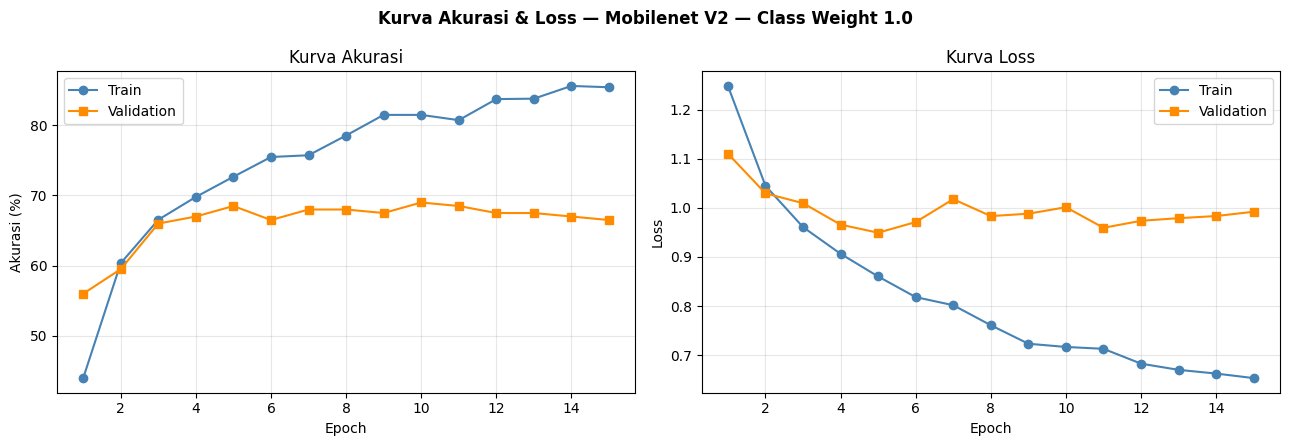


HASIL TEST mobilenet_v2_w1.0:
  Accuracy  : 76.50%
  Precision : 80.96%
  Recall    : 76.50%
  F1 Macro  : 76.14%
  Recall Normal: 52.00%

              precision    recall  f1-score   support

 combination     0.7917    0.7600    0.7755        50
         dry     0.8302    0.8800    0.8544        50
      normal     1.0000    0.5200    0.6842        50
        oily     0.6164    0.9000    0.7317        50

    accuracy                         0.7650       200
   macro avg     0.8096    0.7650    0.7614       200
weighted avg     0.8096    0.7650    0.7614       200



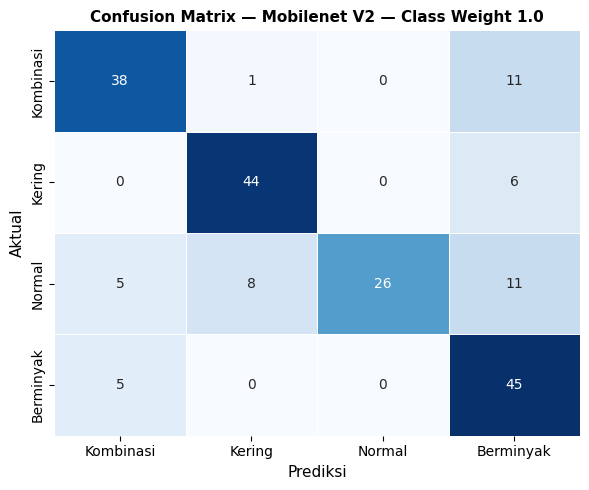

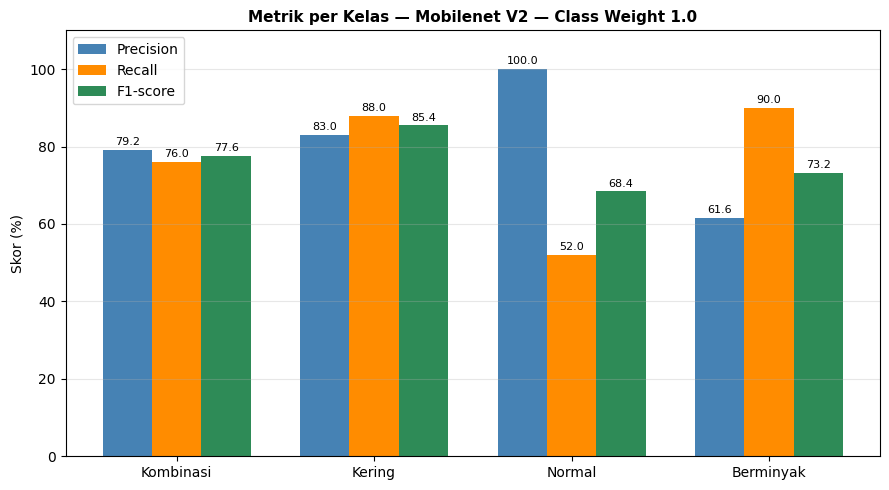


TRAINING: mobilenet_v2  |  NORMAL_WEIGHT = 1.5
Epoch  1 | Acc latih 42.84% | Acc val 51.50% | F1 val 50.37% | Gap -8.7%
Epoch  2 | Acc latih 59.04% | Acc val 59.00% | F1 val 58.64% | Gap +0.0%
Epoch  3 | Acc latih 64.17% | Acc val 66.50% | F1 val 66.28% | Gap -2.3%
Epoch  4 | Acc latih 68.29% | Acc val 66.00% | F1 val 65.81% | Gap +2.3%
Epoch  5 | Acc latih 72.17% | Acc val 68.50% | F1 val 68.38% | Gap +3.7%
Epoch  6 | Acc latih 73.86% | Acc val 66.00% | F1 val 65.90% | Gap +7.9%
Epoch  7 | Acc latih 74.92% | Acc val 67.50% | F1 val 66.95% | Gap +7.4%
Epoch  8 | Acc latih 78.92% | Acc val 65.50% | F1 val 65.34% | Gap +13.4%
Epoch  9 | Acc latih 81.43% | Acc val 65.50% | F1 val 65.01% | Gap +15.9%
Epoch 10 | Acc latih 81.05% | Acc val 69.50% | F1 val 69.09% | Gap +11.6%
Epoch 11 | Acc latih 80.43% | Acc val 68.50% | F1 val 68.32% | Gap +11.9%
Epoch 12 | Acc latih 82.80% | Acc val 70.00% | F1 val 69.68% | Gap +12.8%
Epoch 13 | Acc latih 84.12% | Acc val 67.00% | F1 val 66.67% | Gap +17.

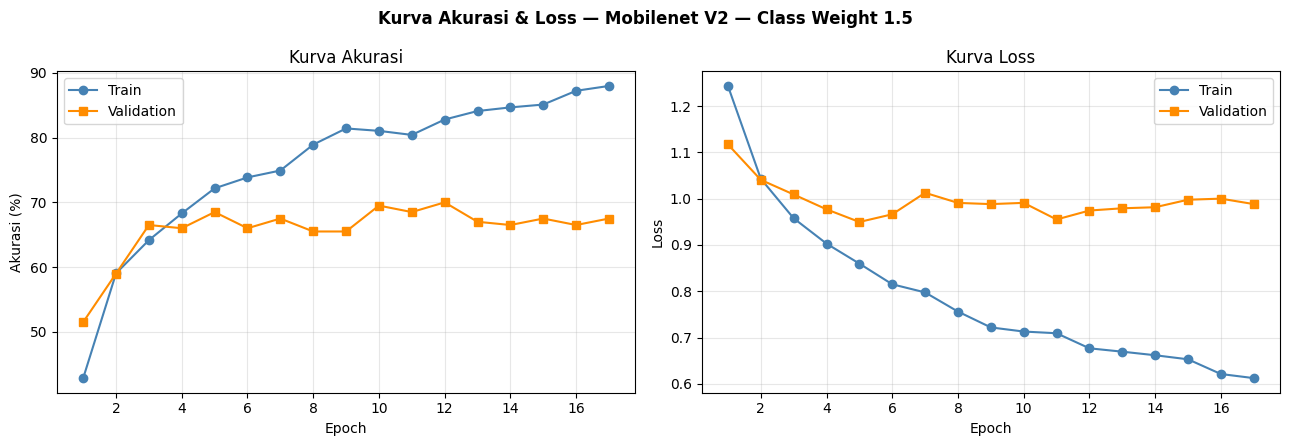


HASIL TEST mobilenet_v2_w1.5:
  Accuracy  : 76.50%
  Precision : 78.25%
  Recall    : 76.50%
  F1 Macro  : 76.27%
  Recall Normal: 60.00%

              precision    recall  f1-score   support

 combination     0.8261    0.7600    0.7917        50
         dry     0.7800    0.7800    0.7800        50
      normal     0.8571    0.6000    0.7059        50
        oily     0.6667    0.9200    0.7731        50

    accuracy                         0.7650       200
   macro avg     0.7825    0.7650    0.7627       200
weighted avg     0.7825    0.7650    0.7627       200



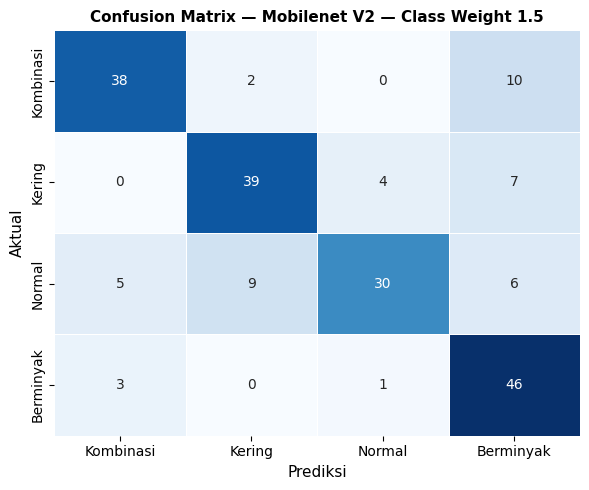

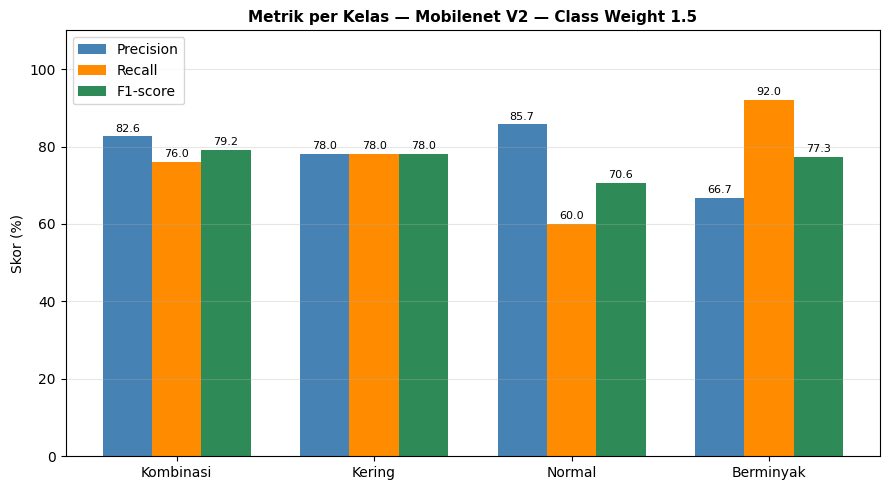


TRAINING: mobilenet_v2  |  NORMAL_WEIGHT = 2.0
Epoch  1 | Acc latih 40.53% | Acc val 51.50% | F1 val 48.65% | Gap -11.0%
Epoch  2 | Acc latih 58.29% | Acc val 56.00% | F1 val 55.14% | Gap +2.3%
Epoch  3 | Acc latih 62.16% | Acc val 62.50% | F1 val 62.42% | Gap -0.3%
Epoch  4 | Acc latih 66.29% | Acc val 65.00% | F1 val 64.79% | Gap +1.3%
Epoch  5 | Acc latih 71.11% | Acc val 67.50% | F1 val 67.42% | Gap +3.6%
Epoch  6 | Acc latih 72.92% | Acc val 64.00% | F1 val 63.94% | Gap +8.9%
Epoch  7 | Acc latih 74.11% | Acc val 67.50% | F1 val 67.10% | Gap +6.6%
Epoch  8 | Acc latih 77.49% | Acc val 66.50% | F1 val 66.47% | Gap +11.0%
Epoch  9 | Acc latih 80.49% | Acc val 69.00% | F1 val 68.72% | Gap +11.5%
Epoch 10 | Acc latih 80.43% | Acc val 68.00% | F1 val 67.67% | Gap +12.4%
Epoch 11 | Acc latih 80.18% | Acc val 69.50% | F1 val 69.42% | Gap +10.7%
Epoch 12 | Acc latih 82.43% | Acc val 70.50% | F1 val 70.26% | Gap +11.9%
Epoch 13 | Acc latih 82.93% | Acc val 67.50% | F1 val 67.24% | Gap +15

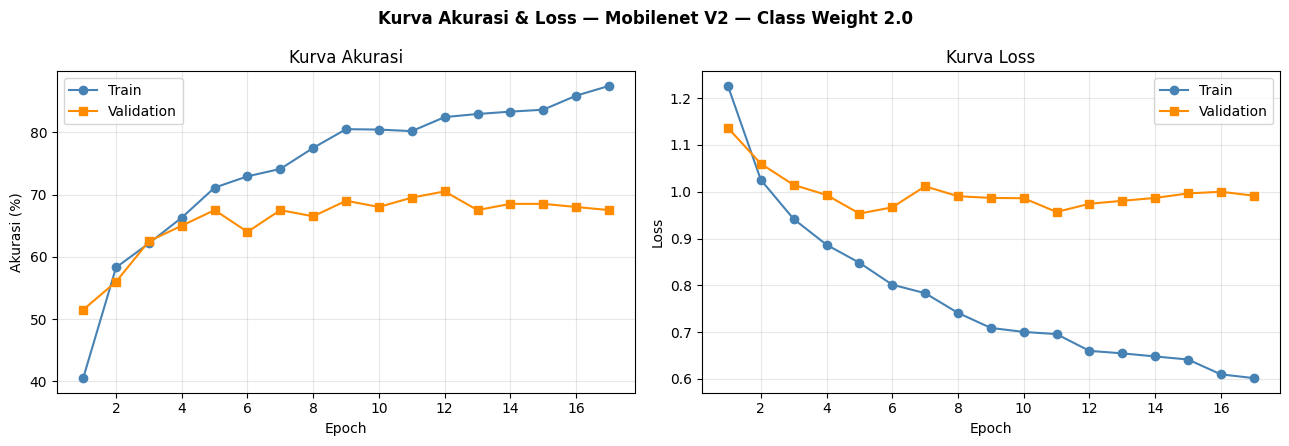


HASIL TEST mobilenet_v2_w2.0:
  Accuracy  : 76.50%
  Precision : 77.93%
  Recall    : 76.50%
  F1 Macro  : 76.40%
  Recall Normal: 66.00%

              precision    recall  f1-score   support

 combination     0.8372    0.7200    0.7742        50
         dry     0.8085    0.7600    0.7835        50
      normal     0.8049    0.6600    0.7253        50
        oily     0.6667    0.9200    0.7731        50

    accuracy                         0.7650       200
   macro avg     0.7793    0.7650    0.7640       200
weighted avg     0.7793    0.7650    0.7640       200



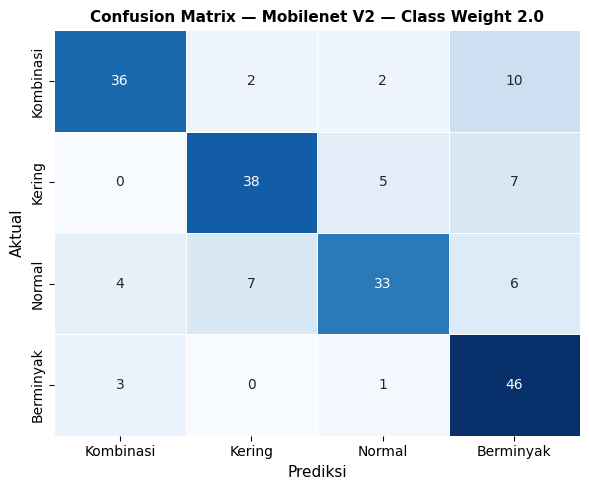

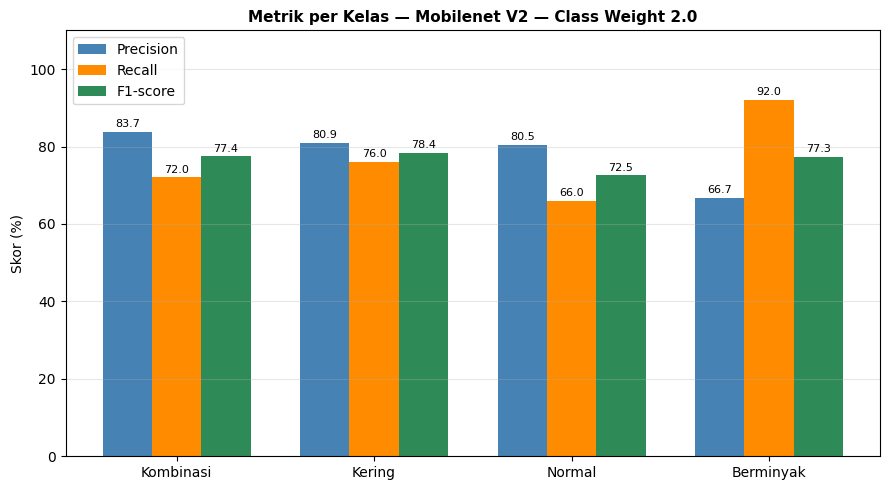


TRAINING: densenet121  |  NORMAL_WEIGHT = 1.0
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 137MB/s] 


Epoch  1 | Acc latih 42.15% | Acc val 53.50% | F1 val 51.72% | Gap -11.3%
Epoch  2 | Acc latih 58.72% | Acc val 62.50% | F1 val 61.93% | Gap -3.8%
Epoch  3 | Acc latih 65.73% | Acc val 65.50% | F1 val 64.46% | Gap +0.2%
Epoch  4 | Acc latih 70.98% | Acc val 66.00% | F1 val 65.55% | Gap +5.0%
Epoch  5 | Acc latih 75.23% | Acc val 66.00% | F1 val 64.98% | Gap +9.2%
Epoch  6 | Acc latih 78.17% | Acc val 66.50% | F1 val 65.59% | Gap +11.7%
Epoch  7 | Acc latih 78.99% | Acc val 70.50% | F1 val 69.63% | Gap +8.5%
Epoch  8 | Acc latih 81.05% | Acc val 71.00% | F1 val 70.22% | Gap +10.1%
Epoch  9 | Acc latih 83.55% | Acc val 69.00% | F1 val 68.37% | Gap +14.6%
Epoch 10 | Acc latih 85.68% | Acc val 73.00% | F1 val 72.84% | Gap +12.7%
Epoch 11 | Acc latih 86.74% | Acc val 66.50% | F1 val 66.04% | Gap +20.2%
Epoch 12 | Acc latih 90.87% | Acc val 66.50% | F1 val 66.01% | Gap +24.4%
Epoch 13 | Acc latih 89.68% | Acc val 69.00% | F1 val 68.30% | Gap +20.7%
Epoch 14 | Acc latih 92.31% | Acc val 69.50

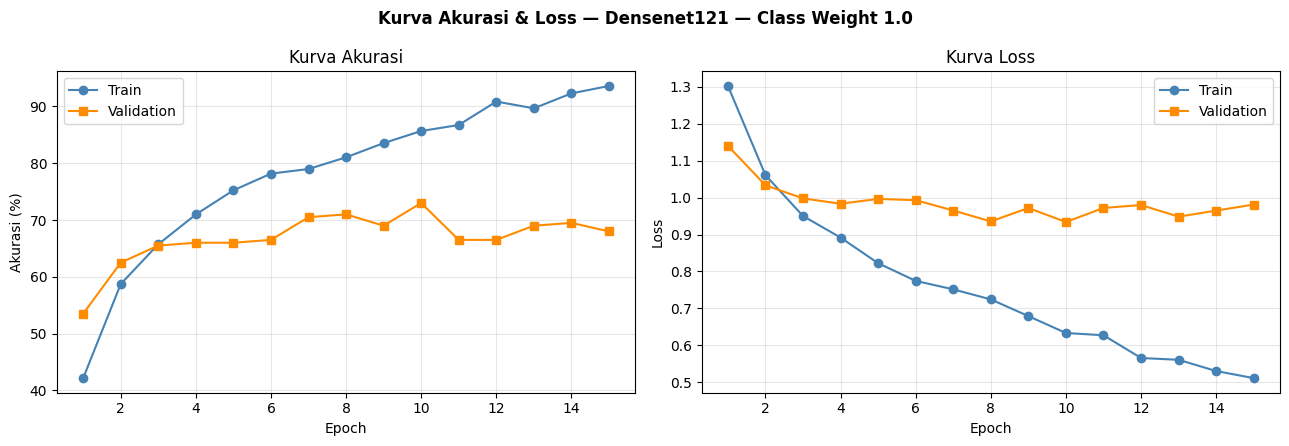


HASIL TEST densenet121_w1.0:
  Accuracy  : 76.50%
  Precision : 77.10%
  Recall    : 76.50%
  F1 Macro  : 75.46%
  Recall Normal: 48.00%

              precision    recall  f1-score   support

 combination     0.8039    0.8200    0.8119        50
         dry     0.7500    0.8400    0.7925        50
      normal     0.8000    0.4800    0.6000        50
        oily     0.7302    0.9200    0.8142        50

    accuracy                         0.7650       200
   macro avg     0.7710    0.7650    0.7546       200
weighted avg     0.7710    0.7650    0.7546       200



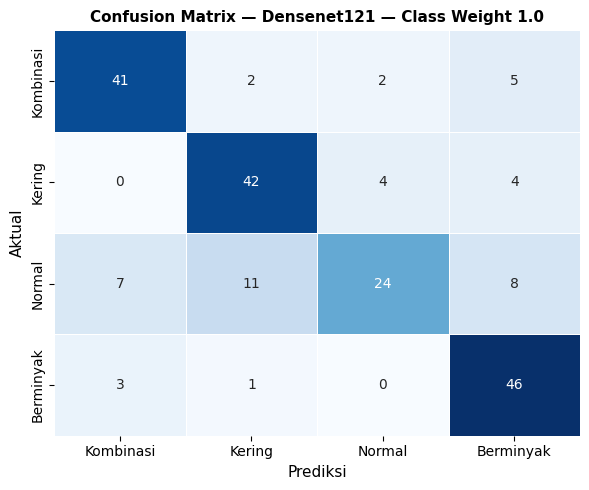

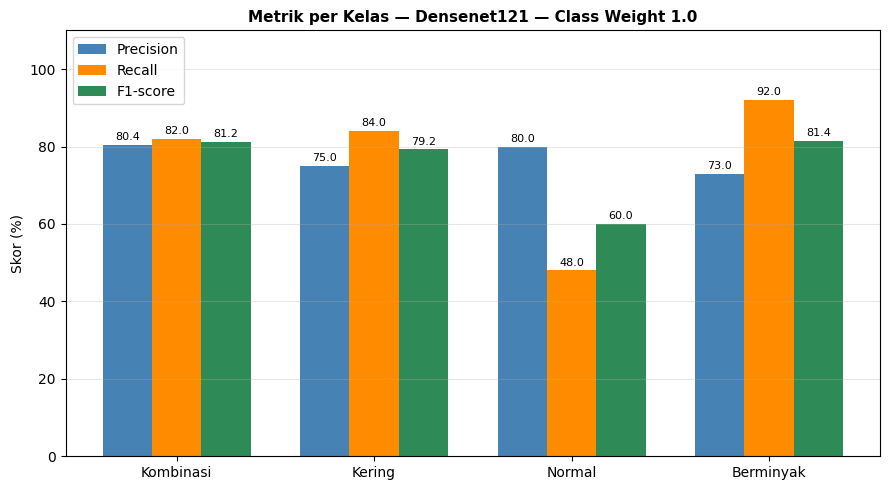


TRAINING: densenet121  |  NORMAL_WEIGHT = 1.5
Epoch  1 | Acc latih 40.84% | Acc val 56.50% | F1 val 55.18% | Gap -15.7%
Epoch  2 | Acc latih 57.72% | Acc val 62.50% | F1 val 62.39% | Gap -4.8%
Epoch  3 | Acc latih 65.67% | Acc val 64.50% | F1 val 64.02% | Gap +1.2%
Epoch  4 | Acc latih 70.17% | Acc val 67.50% | F1 val 67.34% | Gap +2.7%
Epoch  5 | Acc latih 73.61% | Acc val 66.00% | F1 val 65.42% | Gap +7.6%
Epoch  6 | Acc latih 77.05% | Acc val 67.50% | F1 val 67.24% | Gap +9.5%
Epoch  7 | Acc latih 78.42% | Acc val 70.50% | F1 val 69.96% | Gap +7.9%
Epoch  8 | Acc latih 79.80% | Acc val 73.50% | F1 val 73.20% | Gap +6.3%
Epoch  9 | Acc latih 83.68% | Acc val 69.50% | F1 val 69.19% | Gap +14.2%
Epoch 10 | Acc latih 84.37% | Acc val 74.50% | F1 val 74.29% | Gap +9.9%
Epoch 11 | Acc latih 85.37% | Acc val 71.00% | F1 val 70.96% | Gap +14.4%
Epoch 12 | Acc latih 89.87% | Acc val 68.50% | F1 val 68.21% | Gap +21.4%
Epoch 13 | Acc latih 89.06% | Acc val 70.00% | F1 val 69.92% | Gap +19.1%

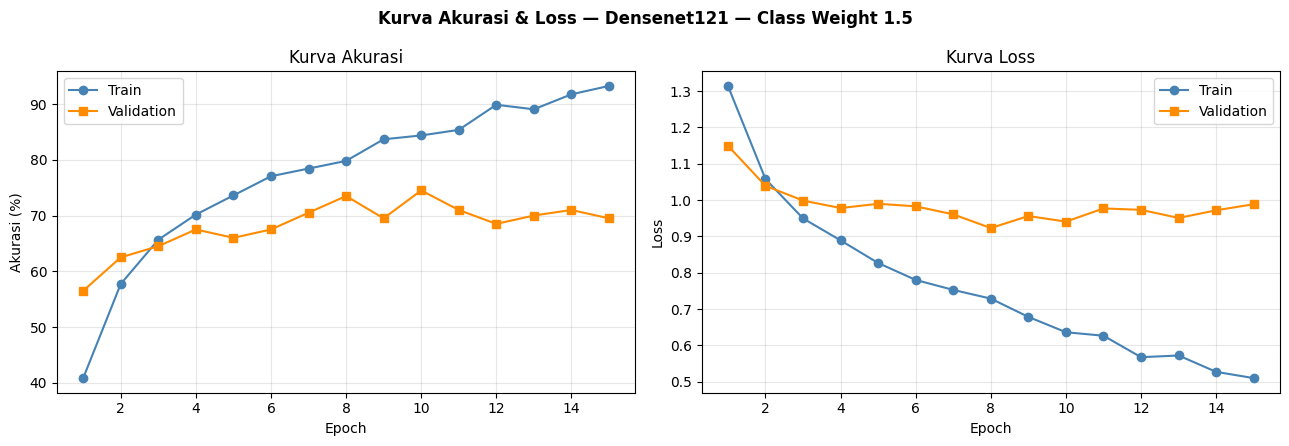


HASIL TEST densenet121_w1.5:
  Accuracy  : 76.50%
  Precision : 76.88%
  Recall    : 76.50%
  F1 Macro  : 75.58%
  Recall Normal: 50.00%

              precision    recall  f1-score   support

 combination     0.7959    0.7800    0.7879        50
         dry     0.7679    0.8600    0.8113        50
      normal     0.7812    0.5000    0.6098        50
        oily     0.7302    0.9200    0.8142        50

    accuracy                         0.7650       200
   macro avg     0.7688    0.7650    0.7558       200
weighted avg     0.7688    0.7650    0.7558       200



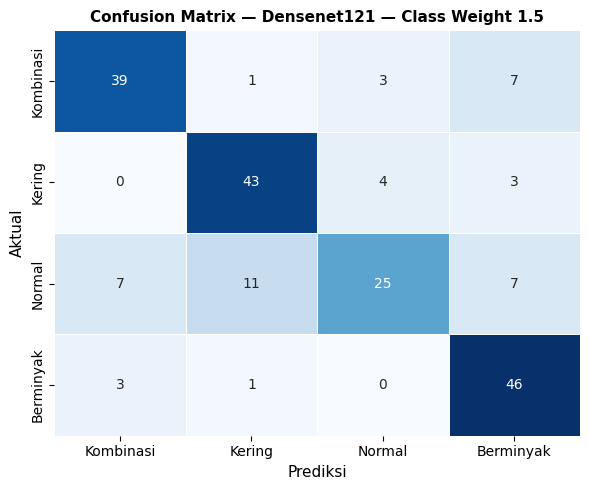

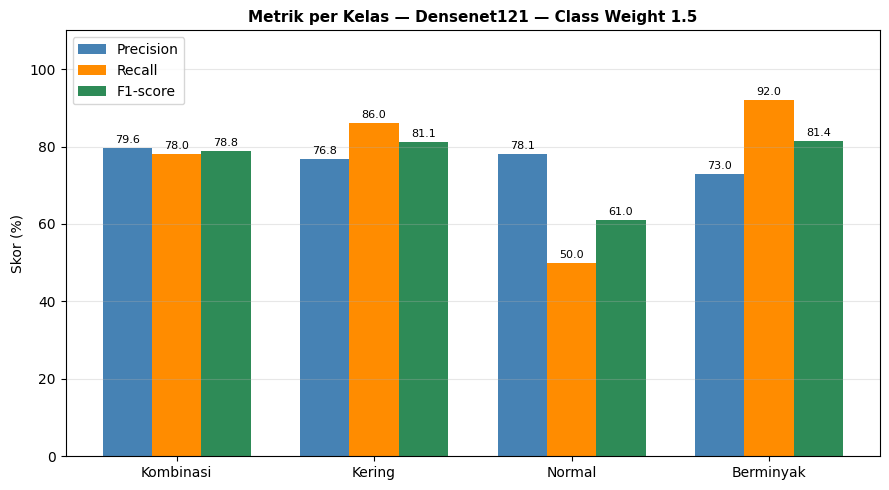


TRAINING: densenet121  |  NORMAL_WEIGHT = 2.0
Epoch  1 | Acc latih 39.21% | Acc val 56.00% | F1 val 54.49% | Gap -16.8%
Epoch  2 | Acc latih 54.41% | Acc val 62.00% | F1 val 61.87% | Gap -7.6%
Epoch  3 | Acc latih 63.91% | Acc val 65.00% | F1 val 64.80% | Gap -1.1%
Epoch  4 | Acc latih 68.48% | Acc val 67.50% | F1 val 67.46% | Gap +1.0%
Epoch  5 | Acc latih 72.86% | Acc val 67.00% | F1 val 66.73% | Gap +5.9%
Epoch  6 | Acc latih 75.05% | Acc val 68.50% | F1 val 68.36% | Gap +6.5%
Epoch  7 | Acc latih 77.36% | Acc val 69.50% | F1 val 69.23% | Gap +7.9%
Epoch  8 | Acc latih 79.61% | Acc val 70.50% | F1 val 70.31% | Gap +9.1%
Epoch  9 | Acc latih 82.61% | Acc val 70.00% | F1 val 69.79% | Gap +12.6%
Epoch 10 | Acc latih 83.68% | Acc val 72.00% | F1 val 71.93% | Gap +11.7%
Epoch 11 | Acc latih 85.55% | Acc val 71.50% | F1 val 71.37% | Gap +14.1%
Epoch 12 | Acc latih 88.62% | Acc val 71.00% | F1 val 70.80% | Gap +17.6%
Epoch 13 | Acc latih 88.18% | Acc val 70.50% | F1 val 70.11% | Gap +17.7

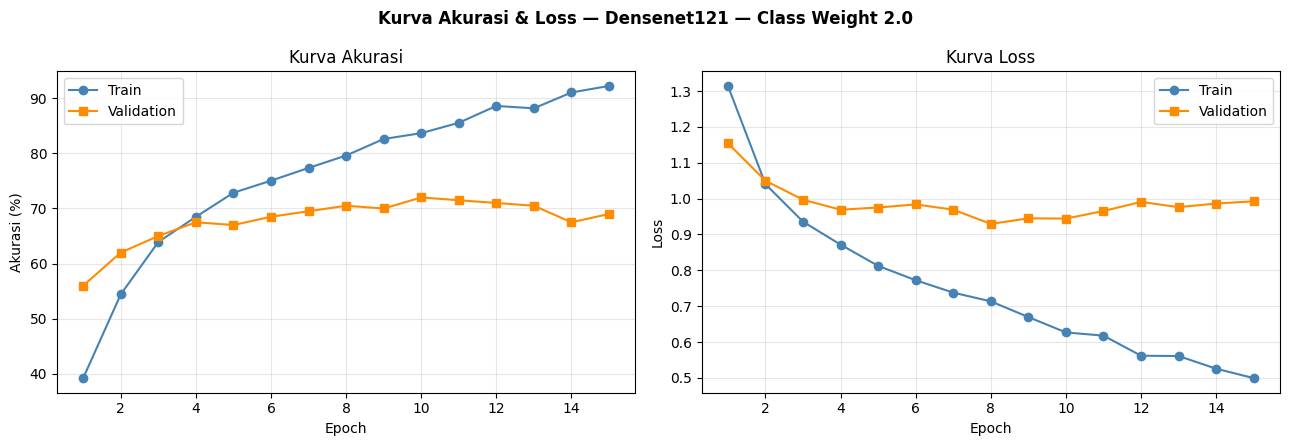


HASIL TEST densenet121_w2.0:
  Accuracy  : 77.50%
  Precision : 77.59%
  Recall    : 77.50%
  F1 Macro  : 76.79%
  Recall Normal: 54.00%

              precision    recall  f1-score   support

 combination     0.8298    0.7800    0.8041        50
         dry     0.7778    0.8400    0.8077        50
      normal     0.7500    0.5400    0.6279        50
        oily     0.7460    0.9400    0.8319        50

    accuracy                         0.7750       200
   macro avg     0.7759    0.7750    0.7679       200
weighted avg     0.7759    0.7750    0.7679       200



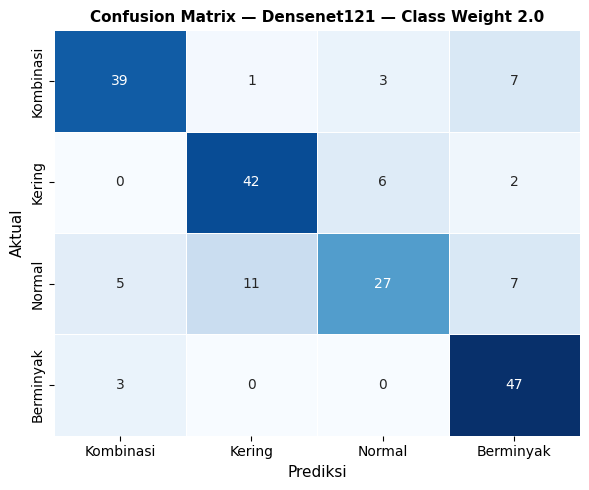

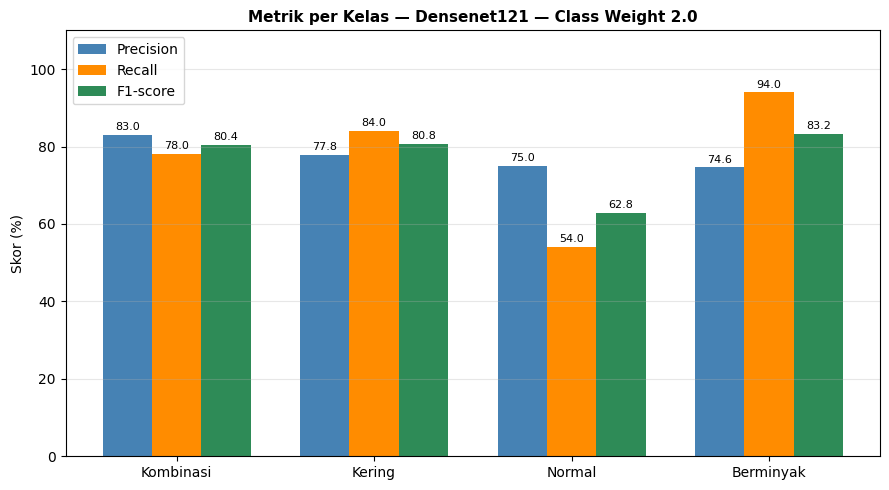


Semua skenario selesai. Hasil disimpan ke hasil_perbandingan.json


In [6]:
# ================================================================
# SEL 6: JALANKAN 9 SKENARIO
# ================================================================
# Urutan: EfficientNet w1.0 → w1.5 → w2.0
#         MobileNetV2  w1.0 → w1.5 → w2.0
#         DenseNet121  w1.0 → w1.5 → w2.0
# ================================================================

hasil = {}  # hasil[arch][bobot] = dict metrik

for arch in DAFTAR_ARSITEKTUR:
    hasil[arch] = {}
    for bobot in DAFTAR_BOBOT:
        hasil[arch][bobot] = latih_dan_evaluasi(arch, bobot)

# Simpan hasil ke JSON
hasil_json = {}
for arch in DAFTAR_ARSITEKTUR:
    hasil_json[arch] = {}
    for bobot in DAFTAR_BOBOT:
        m = hasil[arch][bobot]
        hasil_json[arch][str(bobot)] = {
            "akurasi":       round(m["akurasi"]       * 100, 2),
            "presisi":       round(m["presisi"]       * 100, 2),
            "recall":        round(m["recall"]        * 100, 2),
            "f1":            round(m["f1"]            * 100, 2),
            "recall_normal": round(m["recall_normal"] * 100, 2),
        }

with open("/kaggle/working/hasil_perbandingan.json", "w") as f:
    json.dump(hasil_json, f, indent=2)

print("\nSemua skenario selesai. Hasil disimpan ke hasil_perbandingan.json")

In [7]:
# ================================================================
# SEL 7: TABEL PERBANDINGAN
# ================================================================

no = 1
print(f"{'No':<4} {'Arsitektur':<18} {'CW':<6} "
      f"{'Acc(%)':<10} {'F1(%)':<10} {'Recall Normal(%)':<18}")
print("-" * 68)

for arch in DAFTAR_ARSITEKTUR:
    for bobot in DAFTAR_BOBOT:
        m = hasil[arch][bobot]
        print(f"{no:<4} {arch:<18} {bobot:<6} "
              f"{m['akurasi']*100:<10.2f} "
              f"{m['f1']*100:<10.2f} "
              f"{m['recall_normal']*100:<18.2f}")
        no += 1

print("-" * 68)

No   Arsitektur         CW     Acc(%)     F1(%)      Recall Normal(%)  
--------------------------------------------------------------------
1    efficientnet_b0    1.0    76.00      75.56      50.00             
2    efficientnet_b0    1.5    74.50      74.20      52.00             
3    efficientnet_b0    2.0    75.00      75.02      68.00             
4    mobilenet_v2       1.0    76.50      76.14      52.00             
5    mobilenet_v2       1.5    76.50      76.27      60.00             
6    mobilenet_v2       2.0    76.50      76.40      66.00             
7    densenet121        1.0    76.50      75.46      48.00             
8    densenet121        1.5    76.50      75.58      50.00             
9    densenet121        2.0    77.50      76.79      54.00             
--------------------------------------------------------------------


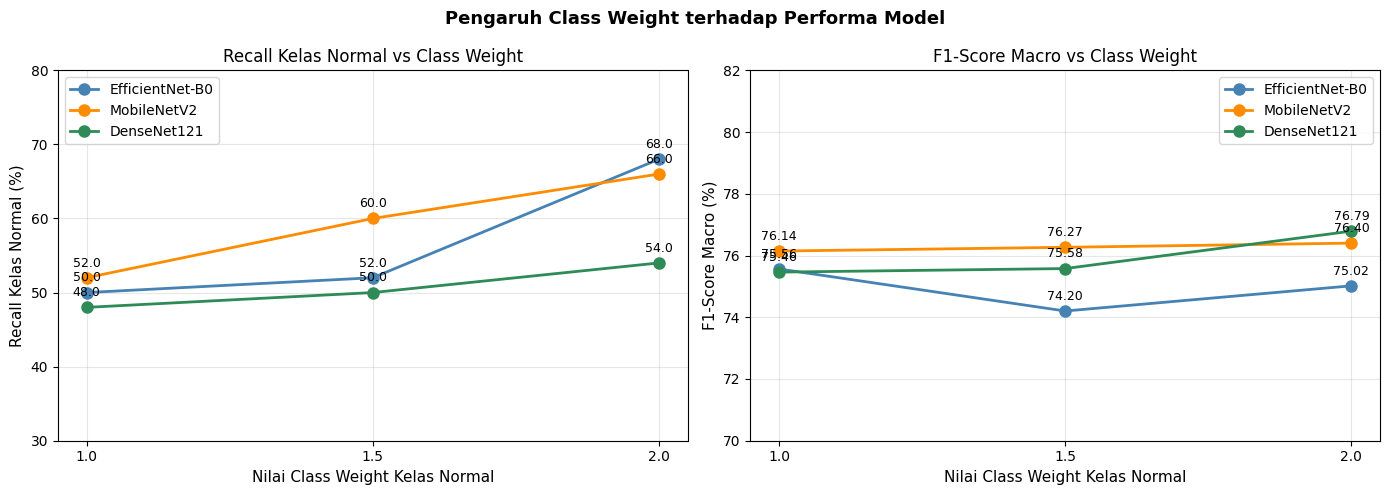

Grafik perbandingan disimpan: 4_perbandingan_cw.png


In [8]:
# ================================================================
# SEL 8: GRAFIK PERBANDINGAN — Recall Normal & F1 Macro vs CW
# ================================================================

warna_arch = {
    "efficientnet_b0": "steelblue",
    "mobilenet_v2":    "darkorange",
    "densenet121":     "seagreen",
}
label_arch = {
    "efficientnet_b0": "EfficientNet-B0",
    "mobilenet_v2":    "MobileNetV2",
    "densenet121":     "DenseNet121",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pengaruh Class Weight terhadap Performa Model",
             fontsize=13, fontweight="bold")

# Grafik kiri: Recall kelas Normal
for arch in DAFTAR_ARSITEKTUR:
    nilai = [hasil[arch][b]["recall_normal"] * 100 for b in DAFTAR_BOBOT]
    axes[0].plot(DAFTAR_BOBOT, nilai, "o-",
                 label=label_arch[arch],
                 color=warna_arch[arch],
                 linewidth=2, markersize=8)
    for x, y in zip(DAFTAR_BOBOT, nilai):
        axes[0].annotate(f"{y:.1f}", (x, y),
                         textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=9)

axes[0].set_xlabel("Nilai Class Weight Kelas Normal", fontsize=11)
axes[0].set_ylabel("Recall Kelas Normal (%)", fontsize=11)
axes[0].set_title("Recall Kelas Normal vs Class Weight")
axes[0].set_xticks(DAFTAR_BOBOT)
axes[0].set_ylim(30, 80)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Grafik kanan: F1 Macro
for arch in DAFTAR_ARSITEKTUR:
    nilai = [hasil[arch][b]["f1"] * 100 for b in DAFTAR_BOBOT]
    axes[1].plot(DAFTAR_BOBOT, nilai, "o-",
                 label=label_arch[arch],
                 color=warna_arch[arch],
                 linewidth=2, markersize=8)
    for x, y in zip(DAFTAR_BOBOT, nilai):
        axes[1].annotate(f"{y:.2f}", (x, y),
                         textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=9)

axes[1].set_xlabel("Nilai Class Weight Kelas Normal", fontsize=11)
axes[1].set_ylabel("F1-Score Macro (%)", fontsize=11)
axes[1].set_title("F1-Score Macro vs Class Weight")
axes[1].set_xticks(DAFTAR_BOBOT)
axes[1].set_ylim(70, 82)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/4_perbandingan_cw.png", dpi=300, bbox_inches="tight")
plt.show()
print("Grafik perbandingan disimpan: 4_perbandingan_cw.png")

In [9]:
# ================================================================
# SEL 9: PENENTUAN MODEL TERBAIK
# ================================================================

print("=" * 60)
print("PERINGKAT 9 SKENARIO (berdasarkan F1 Macro)")
print("=" * 60)

semua = []
for arch in DAFTAR_ARSITEKTUR:
    for bobot in DAFTAR_BOBOT:
        m = hasil[arch][bobot]
        semua.append({
            "arch": arch, "bobot": bobot,
            "akurasi":       m["akurasi"],
            "f1":            m["f1"],
            "recall_normal": m["recall_normal"],
        })

semua_terurut = sorted(semua, key=lambda x: x["f1"], reverse=True)

print(f"{'No':<4} {'Arsitektur':<18} {'CW':<6} "
      f"{'Acc(%)':<10} {'F1(%)':<10} {'Recall Normal(%)':<18}")
print("-" * 68)
for i, k in enumerate(semua_terurut, 1):
    tanda = " <<< TERBAIK" if i == 1 else ""
    print(f"{i:<4} {k['arch']:<18} {k['bobot']:<6} "
          f"{k['akurasi']*100:<10.2f} "
          f"{k['f1']*100:<10.2f} "
          f"{k['recall_normal']*100:<18.2f}{tanda}")

terbaik = semua_terurut[0]
print()
print("=" * 60)
print("MODEL TERBAIK:")
print(f"  Arsitektur    : {terbaik['arch']}")
print(f"  Class Weight  : {terbaik['bobot']}")
print(f"  Accuracy      : {terbaik['akurasi']*100:.2f}%")
print(f"  F1 Macro      : {terbaik['f1']*100:.2f}%")
print(f"  Recall Normal : {terbaik['recall_normal']*100:.2f}%")
print(f"  Checkpoint    : /kaggle/working/best_{terbaik['arch']}_w{terbaik['bobot']}.pth")
print("=" * 60)

PERINGKAT 9 SKENARIO (berdasarkan F1 Macro)
No   Arsitektur         CW     Acc(%)     F1(%)      Recall Normal(%)  
--------------------------------------------------------------------
1    densenet121        2.0    77.50      76.79      54.00              <<< TERBAIK
2    mobilenet_v2       2.0    76.50      76.40      66.00             
3    mobilenet_v2       1.5    76.50      76.27      60.00             
4    mobilenet_v2       1.0    76.50      76.14      52.00             
5    densenet121        1.5    76.50      75.58      50.00             
6    efficientnet_b0    1.0    76.00      75.56      50.00             
7    densenet121        1.0    76.50      75.46      48.00             
8    efficientnet_b0    2.0    75.00      75.02      68.00             
9    efficientnet_b0    1.5    74.50      74.20      52.00             

MODEL TERBAIK:
  Arsitektur    : densenet121
  Class Weight  : 2.0
  Accuracy      : 77.50%
  F1 Macro      : 76.79%
  Recall Normal : 54.00%
  Checkpoint

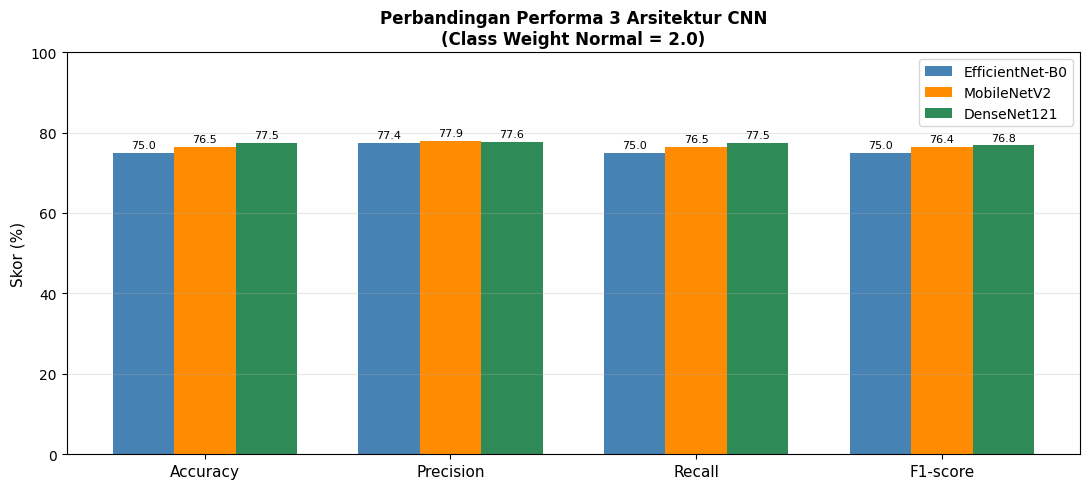


Perbandingan 3 arsitektur pada Class Weight = 2.0:
Arsitektur         Acc(%)     Prec(%)    Rec(%)     F1(%)     
----------------------------------------------------
efficientnet_b0    75.00      77.41      75.00      75.02     
mobilenet_v2       76.50      77.93      76.50      76.40     
densenet121        77.50      77.59      77.50      76.79     


In [10]:
# ================================================================
# SEL 10: GRAFIK PERBANDINGAN 3 ARSITEKTUR PADA CW TERBAIK
# ================================================================

bobot_terbaik = terbaik["bobot"]
metrik_nama   = ["akurasi", "presisi", "recall", "f1"]
label_metrik  = ["Accuracy", "Precision", "Recall", "F1-score"]
posisi        = np.arange(len(metrik_nama))
lebar         = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, arch in enumerate(DAFTAR_ARSITEKTUR):
    m      = hasil[arch][bobot_terbaik]
    nilai  = [m[met] * 100 for met in metrik_nama]
    geser  = (i - 1) * lebar
    warna  = list(warna_arch.values())[i]
    batang = ax.bar(posisi + geser, nilai, lebar,
                    label=label_arch[arch], color=warna)
    ax.bar_label(batang, fmt="%.1f", fontsize=8, padding=2)

ax.set_xticks(posisi)
ax.set_xticklabels(label_metrik, fontsize=11)
ax.set_ylabel("Skor (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.set_title(
    f"Perbandingan Performa 3 Arsitektur CNN\n(Class Weight Normal = {bobot_terbaik})",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/5_perbandingan_arsitektur_cw{bobot_terbaik}.png",
            dpi=300, bbox_inches="tight")
plt.show()

print(f"\nPerbandingan 3 arsitektur pada Class Weight = {bobot_terbaik}:")
print(f"{'Arsitektur':<18} {'Acc(%)':<10} {'Prec(%)':<10} {'Rec(%)':<10} {'F1(%)':<10}")
print("-" * 52)
for arch in DAFTAR_ARSITEKTUR:
    m = hasil[arch][bobot_terbaik]
    print(f"{arch:<18} "
          f"{m['akurasi']*100:<10.2f} "
          f"{m['presisi']*100:<10.2f} "
          f"{m['recall']*100:<10.2f} "
          f"{m['f1']*100:<10.2f}")

In [11]:
# ================================================================
# SEL 11: KONVERSI MODEL TERBAIK KE ONNX (SINGLE FILE)
# ================================================================
arch_terbaik    = terbaik["arch"]
bobot_terbaik   = terbaik["bobot"]
path_checkpoint = f"/kaggle/working/best_{arch_terbaik}_w{bobot_terbaik}.pth"
path_onnx       = f"/kaggle/working/{arch_terbaik}_skin.onnx"

model_final = bangun_model(arch_terbaik)
model_final.load_state_dict(torch.load(path_checkpoint))
model_final.eval()

contoh_masukan = torch.randn(1, 3, UKURAN_CROP, UKURAN_CROP).to(device)

torch.onnx.export(
    model_final,
    contoh_masukan,
    path_onnx,
    input_names=["input"],
    output_names=["output"],
    opset_version=17,
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False,
    export_params=True,
)
print("Export ONNX berhasil (single file).")

path_data = path_onnx + ".data"
if os.path.exists(path_data):
    print("PERINGATAN: .onnx.data masih terbentuk")
else:
    print("OK: model tersimpan sebagai SATU file utuh")

ukuran_mb = os.path.getsize(path_onnx) / (1024 * 1024)
print(f"File: {path_onnx} | Ukuran: {ukuran_mb:.1f} MB")

Opset 17 gagal (No module named 'onnxscript'), mencoba install onnxscript...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 9.6 MB/s eta 0:00:00


/tmp/ipykernel_58/2436159941.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0729 18:25:40.069000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0729 18:25:40.071000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0729 18:25:40.073000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' 

[torch.onnx] Obtain model graph for `DenseNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DenseNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Export ONNX berhasil dengan opset 18.

Model ONNX berhasil disimpan : /kaggle/working/densenet121_skin.onnx
Ukuran model ONNX            : 0.9 MB

Checkpoint terbaik : /kaggle/working/best_densenet121_w2.0.pth
Model ONNX final   : /kaggle/working/densenet121_skin.onnx

Unduh kedua file dari panel Output Kaggle (kanan atas).


In [12]:
# ================================================================
# SEL 12: RINGKASAN AKHIR
# ================================================================

print("=" * 60)
print("RINGKASAN AKHIR PENELITIAN SKINSENSE")
print("=" * 60)
print()
print("Dataset    : Skin Type Classification (4 types) — Kaggle")
print("Total data : 2.000 citra (4 kelas × 500 citra)")
print("Split      : 1600 train / 200 valid / 200 test (80:10:10)")
print()
print("Arsitektur diuji : EfficientNet-B0, MobileNetV2, DenseNet121")
print("Class weight     : 1.0, 1.5, 2.0 (untuk kelas Normal)")
print("Total skenario   : 9 skenario")
print()
print(f"MODEL TERBAIK:")
print(f"  Arsitektur    : {terbaik['arch']}")
print(f"  Class Weight  : {terbaik['bobot']}")
print(f"  Accuracy      : {terbaik['akurasi']*100:.2f}%")
print(f"  F1 Macro      : {terbaik['f1']*100:.2f}%")
print(f"  Recall Normal : {terbaik['recall_normal']*100:.2f}%")
print()
print("File output:")
print(f"  - figures/          : {27 + 5} grafik (kurva, CM, per kelas, perbandingan)")
print(f"  - hasil_perbandingan.json")
print(f"  - best_{terbaik['arch']}_w{terbaik['bobot']}.pth")
print(f"  - {terbaik['arch']}_skin.onnx")
print()
print("Unduh semua file dari panel Output Kaggle.")
print("=" * 60)

RINGKASAN AKHIR PENELITIAN SKINSENSE

Dataset    : Skin Type Classification (4 types) — Kaggle
Total data : 2.000 citra (4 kelas × 500 citra)
Split      : 1600 train / 200 valid / 200 test (80:10:10)

Arsitektur diuji : EfficientNet-B0, MobileNetV2, DenseNet121
Class weight     : 1.0, 1.5, 2.0 (untuk kelas Normal)
Total skenario   : 9 skenario

MODEL TERBAIK:
  Arsitektur    : densenet121
  Class Weight  : 2.0
  Accuracy      : 77.50%
  F1 Macro      : 76.79%
  Recall Normal : 54.00%

File output:
  - figures/          : 32 grafik (kurva, CM, per kelas, perbandingan)
  - hasil_perbandingan.json
  - best_densenet121_w2.0.pth
  - densenet121_skin.onnx

Unduh semua file dari panel Output Kaggle.
